# Tweet Sentiment Classification using Naive Bayes

> **Project Revision Notice**<br>
> This project was originally created in May 2024 as part of my early NLP and machine learning learning journey. In May 2026, I revisited and rebuilt the project to improve the overall workflow, modelling pipeline, evaluation methodology, explainability, and business-oriented analysis.<br>
> You may refer to my GitHub repository for the old version of the notebook.

## ⚙️ Setup and Dataset Loading

In [1]:
# Import libraries
import os
import re
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

In [2]:
# Locate Kaggle input files
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/nlp-getting-started/sample_submission.csv
/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/nlp-getting-started/test.csv


In [3]:
# Load train and test datasets
train_path = None
test_path = None

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        file_path = os.path.join(dirname, filename)

        if filename == "train.csv":
            train_path = file_path
        elif filename == "test.csv":
            test_path = file_path

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (7613, 5)
Test shape: (3263, 4)


In [4]:
# Preview training data
train_df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


In [5]:
# Preview test data
test_df.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, stay safe everyone."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are fleeing across the street, I cannot save them all"
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [6]:
# Check dataset information
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [7]:
# Check missing values
missing_values = train_df.isnull().sum().sort_values(ascending=False)
missing_values

location    2533
keyword       61
id             0
text           0
target         0
dtype: int64

In [8]:
# Check duplicate rows
duplicate_count = train_df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [9]:
# Check target distribution
target_distribution = train_df["target"].value_counts().sort_index()
target_percentage = train_df["target"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_distribution,
    "percentage": target_percentage.round(2)
})

target_summary

,count,percentage
target,,
0,4342,57.03
1,3271,42.97


### Dataset Overview

The dataset contains tweets from Kaggle’s Natural Language Processing with Disaster Tweets competition. Each tweet is labelled as either disaster-related or non-disaster-related.

The training dataset contains 7,613 rows and 5 columns, while the test dataset contains 3,263 rows and 4 columns.

The target variable is moderately balanced:

- Class 0: non-disaster tweets, representing 57.03% of the training data.
- Class 1: disaster-related tweets, representing 42.97% of the training data.

There are no duplicate rows in the training dataset. However, the `location` and `keyword` columns contain missing values. Since the `text` column has no missing values, the first modelling baseline will focus on tweet text only.

## 📊 Exploratory Data Analysis

In [10]:
# Import visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

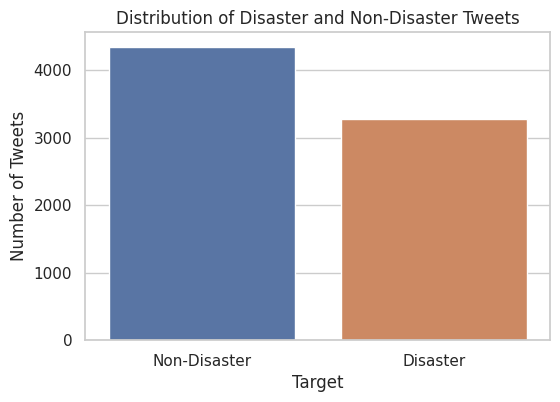

In [11]:
# Plot target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x="target")
plt.title("Distribution of Disaster and Non-Disaster Tweets")
plt.xlabel("Target")
plt.ylabel("Number of Tweets")
plt.xticks(ticks=[0, 1], labels=["Non-Disaster", "Disaster"])
plt.show()

In [12]:
# Create tweet length features
train_df["text_length"] = train_df["text"].str.len()
train_df["word_count"] = train_df["text"].str.split().str.len()

train_df[["text_length", "word_count"]].describe()

,text_length,word_count
count,7613.000000,7613.000000
mean,101.037436,14.903586
std,33.781325,5.732604
min,7.000000,1.000000
25%,78.000000,11.000000
50%,107.000000,15.000000
75%,133.000000,19.000000
max,157.000000,31.000000


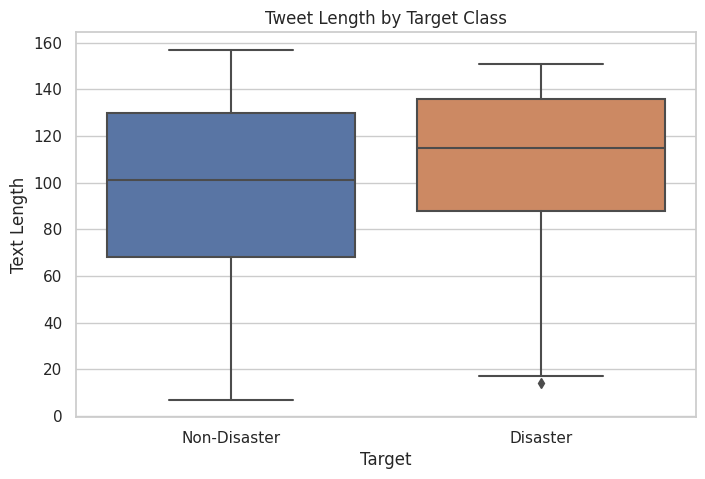

In [13]:
# Compare text length by target
plt.figure(figsize=(8, 5))
sns.boxplot(data=train_df, x="target", y="text_length")
plt.title("Tweet Length by Target Class")
plt.xlabel("Target")
plt.ylabel("Text Length")
plt.xticks(ticks=[0, 1], labels=["Non-Disaster", "Disaster"])
plt.show()

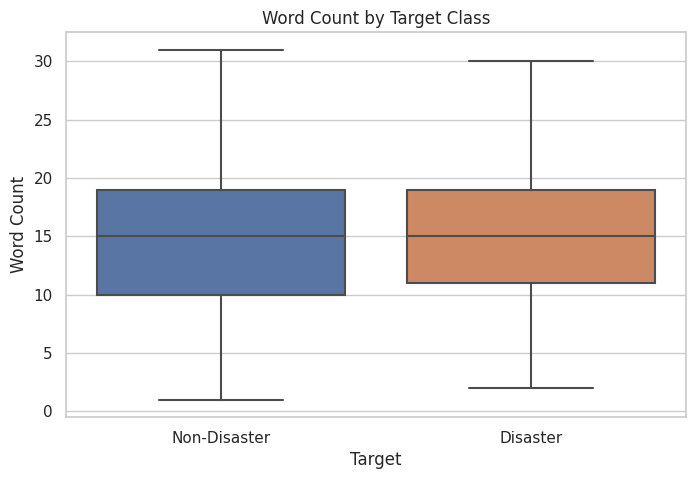

In [14]:
# Compare word count by target
plt.figure(figsize=(8, 5))
sns.boxplot(data=train_df, x="target", y="word_count")
plt.title("Word Count by Target Class")
plt.xlabel("Target")
plt.ylabel("Word Count")
plt.xticks(ticks=[0, 1], labels=["Non-Disaster", "Disaster"])
plt.show()

In [15]:
# Average text length and word count by target
length_summary = train_df.groupby("target")[["text_length", "word_count"]].mean().round(2)
length_summary

,text_length,word_count
target,,
0,95.71,14.70
1,108.11,15.17


In [16]:
# Check most frequent keywords
keyword_summary = train_df["keyword"].value_counts().head(15)
keyword_summary

keyword
fatalities     45
deluge         42
armageddon     42
sinking        41
damage         41
harm           41
body%20bags    41
outbreak       40
evacuate       40
fear           40
collided       40
siren          40
twister        40
windstorm      40
sinkhole       39
Name: count, dtype: int64

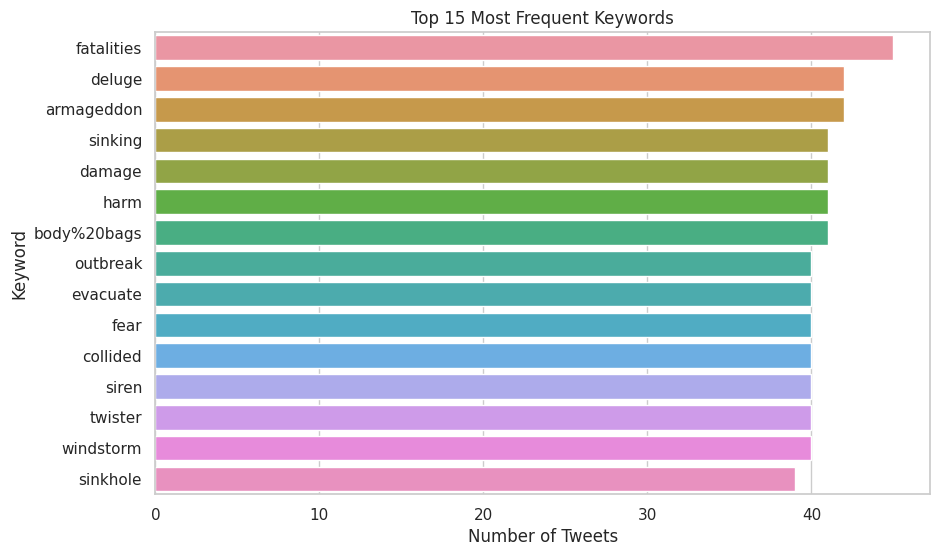

In [17]:
# Plot most frequent keywords
plt.figure(figsize=(10, 6))
sns.barplot(x=keyword_summary.values, y=keyword_summary.index)
plt.title("Top 15 Most Frequent Keywords")
plt.xlabel("Number of Tweets")
plt.ylabel("Keyword")
plt.show()

### Exploratory Data Analysis Insights

The dataset contains slightly more non-disaster tweets than disaster-related tweets, although the class distribution remains reasonably balanced.

Several patterns can be observed from the exploratory analysis:

- Disaster-related tweets tend to contain longer text on average.
- Word count distributions are relatively similar across both classes.
- The dataset contains a variety of disaster-related keywords such as `fatalities`, `deluge`, and `armageddon`.
- Since keyword frequencies are relatively evenly distributed, the semantic content of the tweet text is expected to play a larger role during classification.

These observations suggest that text preprocessing and feature extraction will be important for improving model performance.

## 🧹 Text Preprocessing

In [18]:
# Import NLP libraries
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Error loading punkt: <urlopen error [Errno -3] Temporary
[nltk_data]     failure in name resolution>
[nltk_data] Error loading stopwords: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>


False

In [19]:
# Initialize preprocessing tools
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))

In [20]:
# Define text preprocessing function
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtag symbol only
    text = re.sub(r"#", "", text)

    # Remove punctuation and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Tokenize text
    tokens = word_tokenize(text)

    # Remove stopwords and apply stemming
    processed_tokens = [
        stemmer.stem(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(processed_tokens)

In [21]:
# Apply preprocessing
train_df["clean_text"] = train_df["text"].apply(preprocess_text)
test_df["clean_text"] = test_df["text"].apply(preprocess_text)

In [22]:
# Compare original and cleaned text
comparison_df = pd.DataFrame({
    "original_text": train_df["text"].head(5),
    "clean_text": train_df["clean_text"].head(5)
})

comparison_df

,original_text,clean_text
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deed reason earthquak may allah forgiv
1,Forest fire near La Ronge Sask. Canada,forest fire near rong sask canada
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,resid ask shelter place notifi offic evacu shelter place order expect
3,"13,000 people receive #wildfires evacuation orders in California",peopl receiv wildfir evacu order california
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,got sent photo rubi alaska smoke wildfir pour school


In [23]:
# Check for empty cleaned texts
empty_cleaned_texts = (train_df["clean_text"].str.strip() == "").sum()

print("Empty cleaned texts:", empty_cleaned_texts)

Empty cleaned texts: 3


In [24]:
# Inspect empty cleaned texts
empty_cleaned_rows = train_df[train_df["clean_text"].str.strip() == ""]

empty_cleaned_rows[["text", "target"]]

,text,target
3663,@Truly_Stings Yo Dm me,1
4497,@Hurricane_Dame ???????? I don't have them they out here,1
6766,@Ayshun_Tornado then don't,0


In [25]:
# Replace empty cleaned texts with a placeholder token
train_df["clean_text"] = train_df["clean_text"].replace("", "emptytweet")
test_df["clean_text"] = test_df["clean_text"].replace("", "emptytweet")

print("Empty cleaned texts after replacement:", (train_df["clean_text"].str.strip() == "").sum())

Empty cleaned texts after replacement: 0


### Text Preprocessing

The raw tweet text contains hashtags, mentions, punctuation, URLs, and other noisy patterns that are common in social media data. Before training the model, the text was cleaned and standardized using several preprocessing steps:

- Converted text to lowercase
- Removed URLs and user mentions
- Removed punctuation and numbers
- Tokenized text into individual words
- Removed stopwords
- Applied stemming using Porter Stemmer

The preprocessing step helps reduce noise while preserving important semantic information for classification.

A small number of tweets became empty after preprocessing because they mainly contained mentions, symbols, or stopwords. These rows were replaced with a placeholder token to avoid issues during vectorization.